In [198]:
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as colors
import numpy as np

from sandbox.jordan8 import generate_matrix

from sandbox.plt_dict import matplotlib_update

matplotlib_update()

In [199]:
np.random.seed(2137)

J1, S1 = generate_matrix(d=28, max_block_size=1, eps=1e-3, return_J=True)
J2, S2 = generate_matrix(d=28, max_block_size=4, eps=1e-3, return_J=True)
J3, S3 = generate_matrix(d=28, max_block_size=4, eps=1e-3, return_J=True)   
J4, S4 = generate_matrix(d=28, max_block_size=8, eps=1e-3, return_J=True)

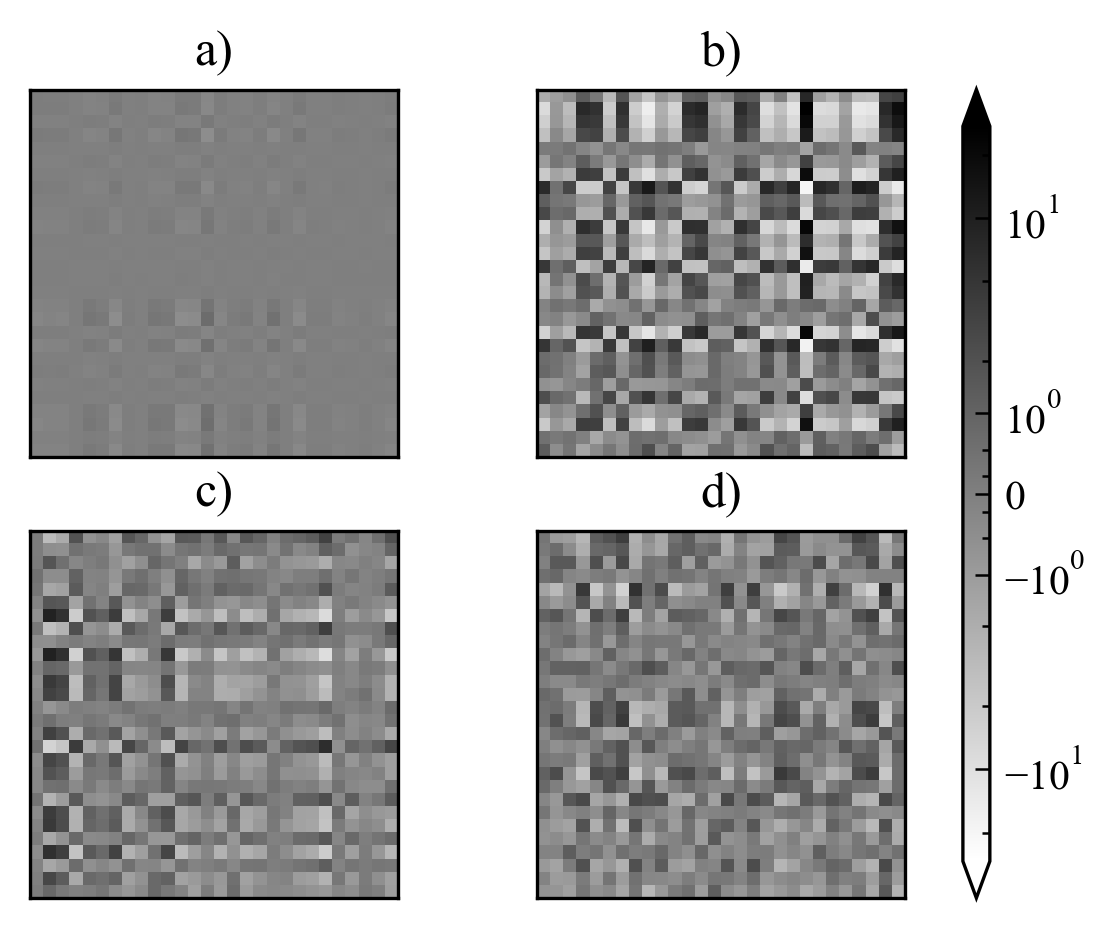

In [ ]:
matrices = [np.linalg.inv(S1)@J1@S1, np.linalg.inv(S2)@J2@S2, np.linalg.inv(S3)@J3@S3, np.linalg.inv(S4)@J4@S4]

global_min = min(np.min(m) for m in matrices)
global_max = max(np.max(m) for m in matrices)
global_min = -max(abs(global_min), abs(global_max))
global_max = max(abs(global_min), abs(global_max))


norm = colors.AsinhNorm(linear_width=1.0, vmin=global_min, vmax=global_max)

fig, axes = plt.subplots(2, 2)
axes = axes.flatten()
letters = ['a', 'b', 'c', 'd']

for i, (ax, mat) in enumerate(zip(axes, matrices)):
    im = ax.matshow(mat, cmap='binary', norm=norm)
    ax.set_title(f"{letters[i]})")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')

# Add the colorbar using the last image object 'im'
# We also manually set ticks if the automatic ones bunch up at the edges
cbar = fig.colorbar(im, ax=axes, orientation='vertical', extend='both', aspect=30, ticks=[10, 1, 0, -1, -10])

# plt.savefig("latex/images/random_matrices.pdf")
plt.show()

In [251]:
np.random.seed(4567)
S = np.random.randn(20,20)
E = np.random.randn(20,20)
S2 = np.random.randn(20,20)
# E = E / np.linalg.norm(E)
E = 1e-2 * E
J1 = np.diag([0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0], k=1) + E
J2 = np.diag([0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0], k=1) + E
J3 = np.diag([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0], k=1) + E
J4 = np.diag([0]*19, k=1) + E
S_inv = np.linalg.inv(S)
S_inv2 = np.linalg.inv(S2)

In [254]:
print(np.linalg.norm(E))

0.1942084785439876


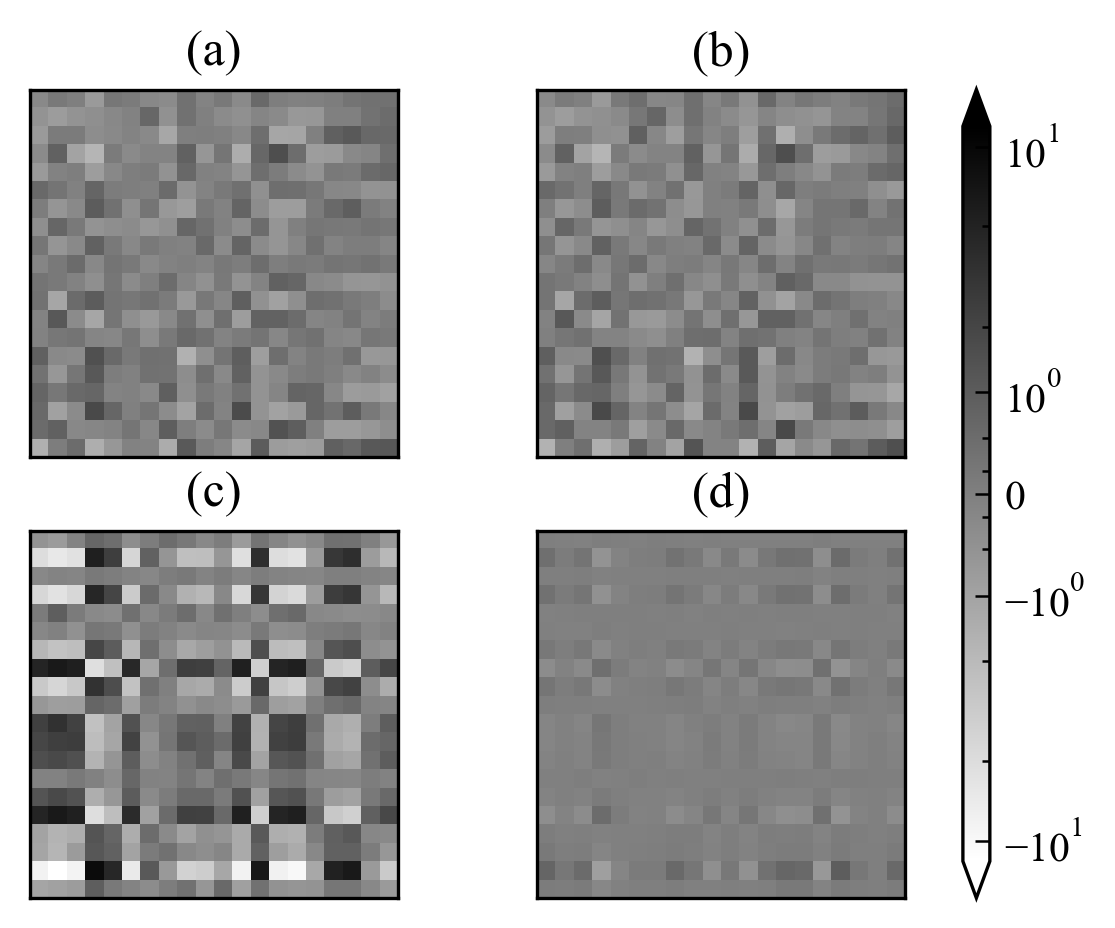

In [253]:
matrices = [S_inv@J1@S, S_inv@J2@S, S_inv2@J3@S2, S_inv2@J4@S2]

global_min = min(np.min(m) for m in matrices)
global_max = max(np.max(m) for m in matrices)
global_min = -max(abs(global_min), abs(global_max))
global_max = max(abs(global_min), abs(global_max))


norm = colors.AsinhNorm(linear_width=1.0, vmin=global_min, vmax=global_max)

fig, axes = plt.subplots(2, 2)
axes = axes.flatten()
letters = ['a', 'b', 'c', 'd']

for i, (ax, mat) in enumerate(zip(axes, matrices)):
    im = ax.matshow(mat, cmap='binary', norm=norm)
    ax.set_title(f"({letters[i]})")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')

# Add the colorbar using the last image object 'im'
# We also manually set ticks if the automatic ones bunch up at the edges
cbar = fig.colorbar(im, ax=axes, orientation='vertical', extend='both', aspect=30, ticks=[10, 1, 0, -1, -10])

plt.savefig("latex/images/random_matrices.pdf")
plt.show()